In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv('content/Tesla.csv')
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,16.110001


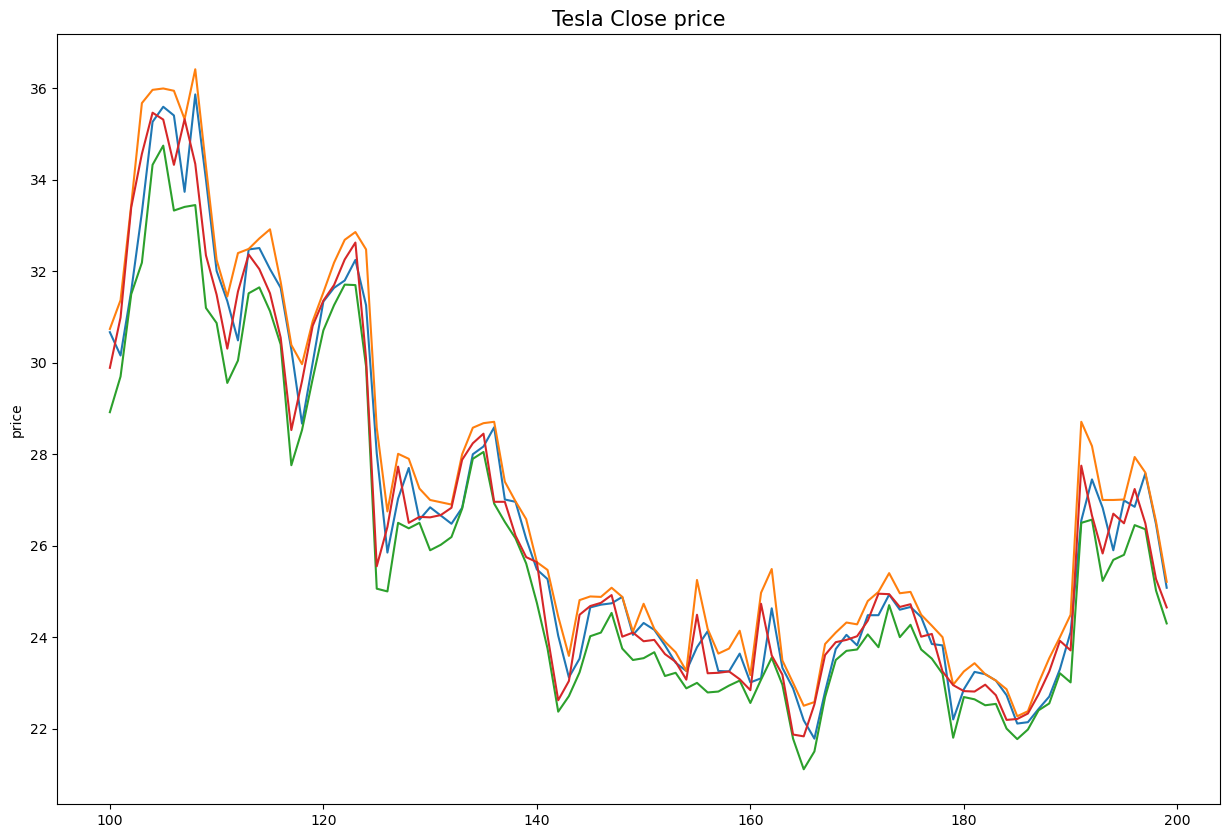

In [23]:
plt.figure(figsize=(15, 10))
plt.plot(df['Open'][100:200])
plt.plot(df['High'][100:200])
plt.plot(df['Low'][100:200])
plt.plot(df['Close'][100:200])
plt.title('Tesla Close price', fontsize = 15)
plt.ylabel('price')
plt.show()

In [24]:
df = df.drop(['Adj Close'], axis=1)

In [25]:
df.head()

,Date,Open,High,Low,Close,Volume
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900


/tmp/ipykernel_35105/3562725223.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
/tmp/ipykernel_35105/3562725223.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
/tmp/ipykernel_35105/3562725223.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed i

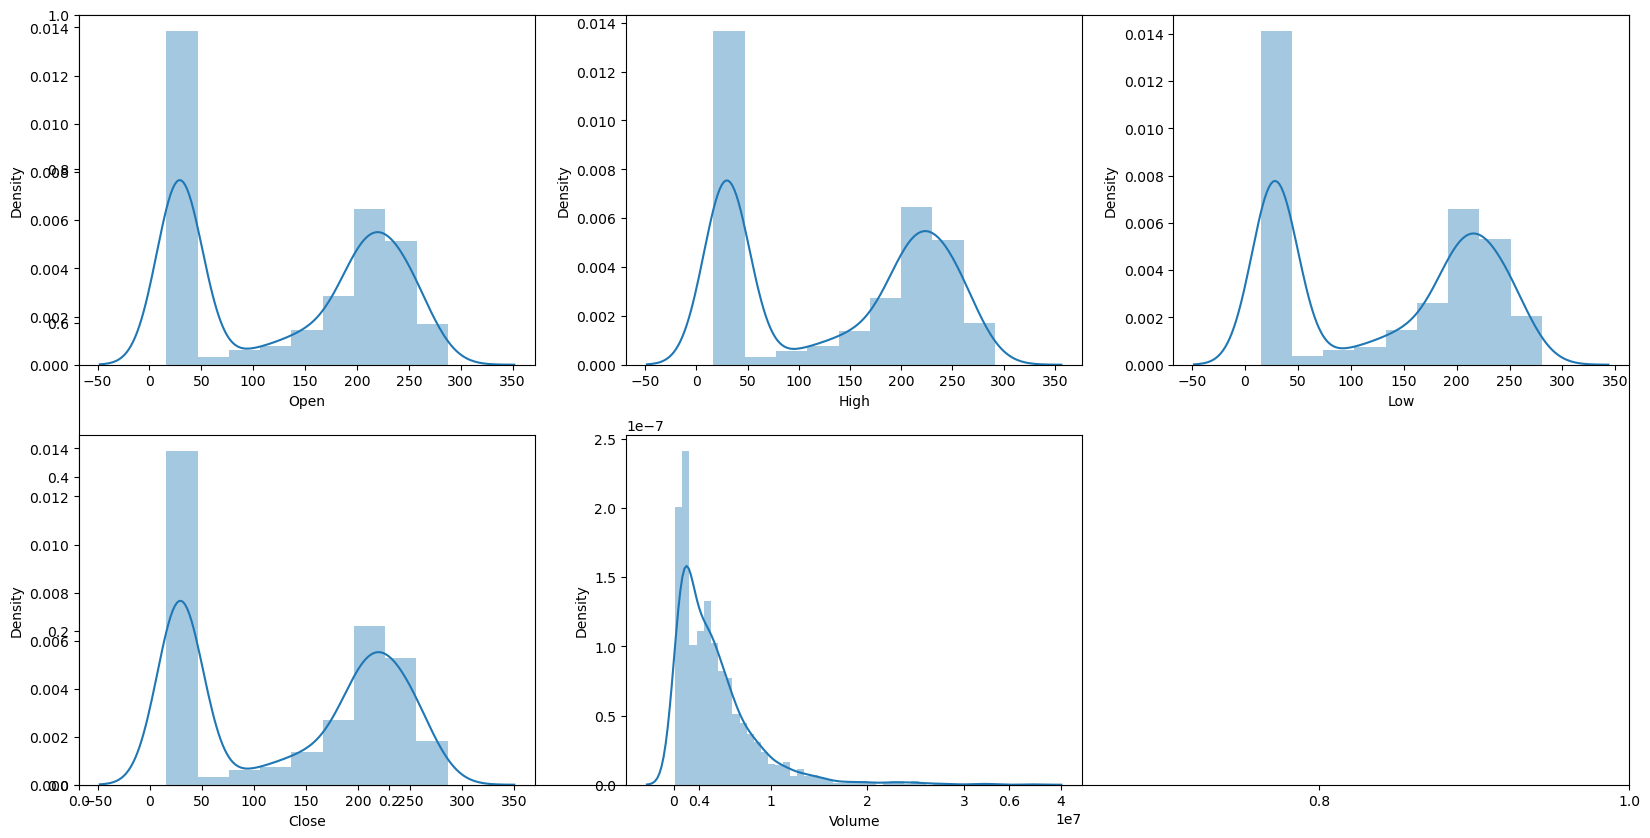

In [26]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']
plt.subplots(figsize=(20, 10))

for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    sns.distplot(df[col])
    # sns.boxenplot(df[col])

plt.show()

In [27]:
splitted = df['Date'].str.split('/', expand=True)

In [28]:
df['day'] = splitted[1].astype('int')
df['month'] = splitted[0].astype('int')
df['year'] = splitted[2].astype('int')

In [29]:
df['is_quarter_end'] = np.where(df['month']%3==0,1,0)
df.head()

,Date,Open,High,Low,Close,Volume,day,month,year,is_quarter_end
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,29,6,2010,1
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,30,6,2010,1
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,1,7,2010,0
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,2,7,2010,0
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,6,7,2010,0


In [30]:
df['open-close'] = df['Open'] - df['Close']
df['low-high'] = df['Low'] - df['High']
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)
df['next_open'] = df['Open'].shift(-1)
df['next_close'] = df['Close'].shift(-1)
df['next_high'] = df['High'].shift(-1)
df['next_low'] = df['Low'].shift(-1)

In [31]:
raw_total = df

In [32]:
raw_total.head()

,Date,Open,High,Low,Close,Volume,day,month,year,is_quarter_end,open-close,low-high,target,next_open,next_close,next_high,next_low
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,29,6,2010,1,-4.889999,-7.459999,0,25.790001,23.830000,30.420000,23.299999
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,30,6,2010,1,1.960001,-7.120001,0,25.000000,21.959999,25.920000,20.270000
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,1,7,2010,0,3.040001,-5.650000,0,23.000000,19.200001,23.100000,18.709999
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,2,7,2010,0,3.799999,-4.390001,0,20.000000,16.110001,20.000000,15.830000
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,6,7,2010,0,3.889999,-4.170000,0,16.400000,15.800000,16.629999,14.980000


In [33]:
raw_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1692 non-null   object 
 1   Open            1692 non-null   float64
 2   High            1692 non-null   float64
 3   Low             1692 non-null   float64
 4   Close           1692 non-null   float64
 5   Volume          1692 non-null   int64  
 6   day             1692 non-null   int64  
 7   month           1692 non-null   int64  
 8   year            1692 non-null   int64  
 9   is_quarter_end  1692 non-null   int64  
 10  open-close      1692 non-null   float64
 11  low-high        1692 non-null   float64
 12  target          1692 non-null   int64  
 13  next_open       1691 non-null   float64
 14  next_close      1691 non-null   float64
 15  next_high       1691 non-null   float64
 16  next_low        1691 non-null   float64
dtypes: float64(10), int64(6), object(

In [34]:
raw_total.dropna(inplace=True)

In [35]:
from sklearn.preprocessing import StandardScaler
features = raw_total[['open-close', 'low-high', 'is_quarter_end', 'Open', 'Close', 'High', 'Low']]
target = raw_total[['target', 'next_open',  'next_close', 'next_high', 'next_low']].values

scaler = StandardScaler()
features = scaler.fit_transform(features)

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb
from sklearn import metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [37]:
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [38]:
model_logistic_reg = LogisticRegression()
model_logistic_reg.fit(x_train, y_train[:,0])

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [39]:
y_pred = model_logistic_reg.predict(x_test)

In [40]:
print("Accuracy:", accuracy_score(y_test[:,0], y_pred))
print(classification_report(y_test[:,0], y_pred))

Accuracy: 0.5014749262536873
              precision    recall  f1-score   support

         0.0       0.51      0.18      0.26       170
         1.0       0.50      0.83      0.62       169

    accuracy                           0.50       339
   macro avg       0.50      0.50      0.44       339
weighted avg       0.50      0.50      0.44       339



In [41]:
from sklearn.cluster import KMeans

kmeans_classifier = KMeans(n_clusters=2, random_state=42)
kmeans_classifier.fit(x_test)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


              precision    recall  f1-score   support

           0       0.52      0.53      0.53       169
           1       0.53      0.52      0.53       170

    accuracy                           0.53       339
   macro avg       0.53      0.53      0.53       339
weighted avg       0.53      0.53      0.53       339



<Axes: >

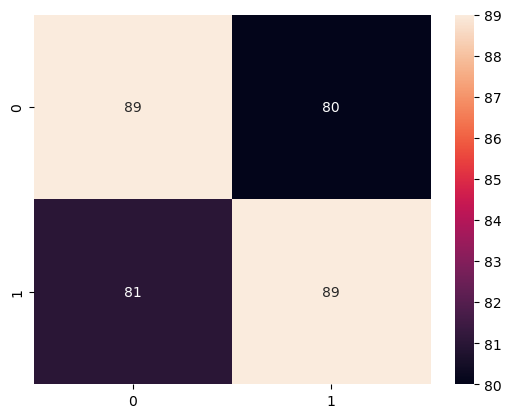

In [42]:
print(classification_report(kmeans_classifier.labels_, y_test[:,0]))
sns.heatmap(confusion_matrix(kmeans_classifier.labels_, y_test[:,0]), annot=True)

In [44]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

model_decision_tree = DecisionTreeClassifier(
    criterion='entropy',      # measure purity using information gain
    max_depth=4,              # limit tree depth
    min_samples_split=10,     # at least 10 samples to split
    min_samples_leaf=5,       # at least 5 samples in a leaf
    random_state=42
)

model_decision_tree.fit(x_train, y_train[:,0])

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
y_pred = model_decision_tree.predict(x_test)

In [ ]:
print(classification_report(y_test[:,0], y_pred))
sns.heatmap(confusion_matrix(y_test[:,0], y_pred), annot=True)

In [45]:
from sklearn.ensemble import RandomForestClassifier

model_random_forest = RandomForestClassifier(n_estimators=120, max_features=3)
model_random_forest.fit(x_train, y_train[:,0])

,n_estimators,120
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
y_pred = model_random_forest.predict(x_test)

              precision    recall  f1-score   support

         0.0       0.47      0.45      0.46       170
         1.0       0.47      0.50      0.48       169

    accuracy                           0.47       339
   macro avg       0.47      0.47      0.47       339
weighted avg       0.47      0.47      0.47       339



<Axes: >

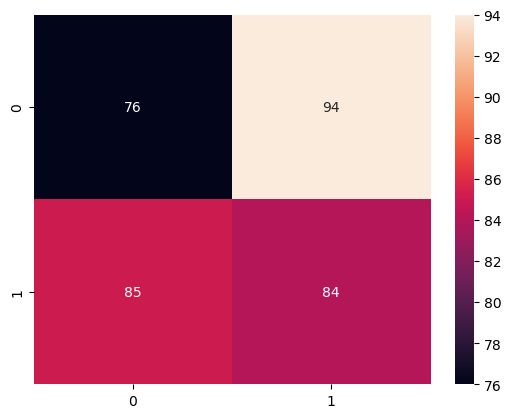

In [47]:
print(classification_report(y_test[:,0], y_pred))
sns.heatmap(confusion_matrix(y_test[:,0], y_pred), annot=True)

In [48]:
from sklearn.ensemble import RandomForestRegressor

model_random_forest_reg = RandomForestRegressor(n_estimators=100)
model_random_forest_reg.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
y_pred = model_random_forest_reg.predict(x_test)

In [50]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.7616499448020188


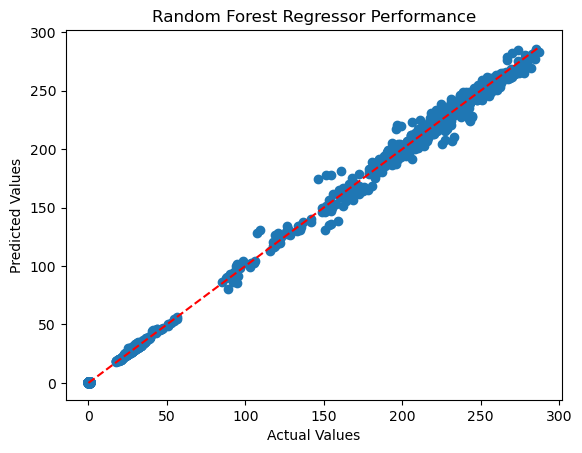

In [51]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regressor Performance")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # reference line
plt.show()

/home/bigben/miniconda3/envs/data_analysis/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:22:49] WARNING: /croot/xgboost-split_1749630910898/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📈 1
📉 1.0
📈 0
📉 1.0
📈 1
📉 0.0
📈 1
📉 0.0
📈 0
📉 1.0
📈 1
📉 1.0
📈 1
📉 0.0
📈 1
📉 0.0
📈 1
📉 1.0
📈 0
📉 0.0
📈 1
📉 0.0
📈 1
📉 0.0
📈 1
📉 1.0
📈 1
📉 0.0
📈 0
📉 0.0
📈 0
📉 0.0
📈 1
📉 0.0
📈 1
📉 1.0
📈 1
📉 1.0
📈 1
📉 1.0
📈 1
📉 0.0
📈 0
📉 0.0
📈 0
📉 0.0
📈 0
📉 1.0
📈 0
📉 1.0
📈 1
📉 1.0
📈 1
📉 0.0
📈 0
📉 1.0
📈 1
📉 1.0
📈 1
📉 1.0
📈 1
📉 1.0
📈 0
📉 0.0
📈 0
📉 1.0
📈 0
📉 0.0
📈 0
📉 0.0
📈 1
📉 1.0
📈 1
📉 1.0
📈 0
📉 1.0
📈 0
📉 1.0
📈 1
📉 0.0
📈 1
📉 0.0
📈 1
📉 0.0
📈 0
📉 0.0
📈 1
📉 0.0
📈 0
📉 1.0
📈 1
📉 1.0
📈 0
📉 0.0
📈 0
📉 0.0
📈 1
📉 1.0
📈 0
📉 0.0
📈 0
📉 1.0
📈 1
📉 1.0
📈 1
📉 1.0
📈 1
📉 1.0
📈 0
📉 1.0
📈 1
📉 0.0
📈 1
📉 1.0
📈 0
📉 1.0
📈 0
📉 0.0
📈 1
📉 0.0
📈 1
📉 0.0
📈 0
📉 0.0
📈 0
📉 1.0
📈 1
📉 0.0
📈 1
📉 0.0
📈 1
📉 1.0
📈 0
📉 0.0
📈 1
📉 1.0
📈 0
📉 0.0
📈 1
📉 0.0
📈 0
📉 1.0
📈 0
📉 1.0
📈 0
📉 0.0
📈 1
📉 0.0
📈 0
📉 1.0
📈 1
📉 0.0
📈 0
📉 0.0
📈 1
📉 0.0
📈 0
📉 1.0
📈 1
📉 1.0
📈 0
📉 0.0
📈 0
📉 1.0
📈 1
📉 1.0
📈 1
📉 0.0
📈 1
📉 1.0
📈 1
📉 0.0
📈 0
📉 0.0
📈 1
📉 1.0
📈 0
📉 0.0
📈 1
📉 1.0
📈 0
📉 1.0
📈 1
📉 0.0
📈 1
📉 0.0
📈 1
📉 0.0
📈 0
📉 1.0
📈 1
📉 0.0
📈 1
📉 0.0
📈 1
📉 1.0
📈 1
📉 0.0
📈 1
📉 1.0


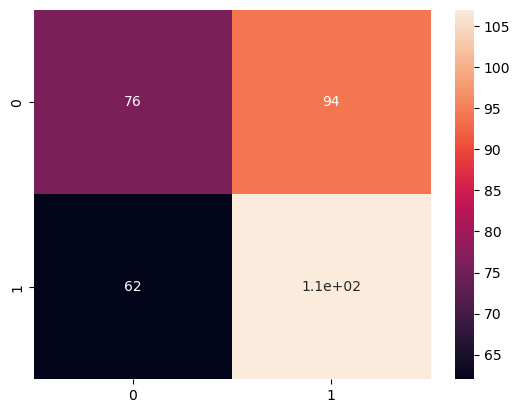

In [ ]:
model_xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,       # number of trees
    learning_rate=0.1,      # step size shrinkage
    max_depth=3,            # maximum depth of trees
    random_state=42,
    use_label_encoder=False,  # to suppress warning
    eval_metric='logloss'     # metric for binary classification
)

# Step 5: Train the model
model_xgb_classifier.fit(x_train, y_train[:,0])

# Step 6: Predictions
y_pred = model_xgb_classifier.predict(x_test)

# Step 7: Evaluate
print("Accuracy:", accuracy_score(y_test[:,0], y_pred))
print("\nClassification Report:\n", classification_report(y_test[:,0], y_pred))
print(sns.heatmap(confusion_matrix(y_test[:,0], y_pred), annot=True))

In [58]:
from sklearn.metrics import mean_squared_error

model_xgb_regressor = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train model
model_xgb_regressor.fit(x_train, y_train)

# Predict
y_pred = model_xgb_regressor.predict(x_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 14.351636727618246
R² Score: 0.7855493567720704


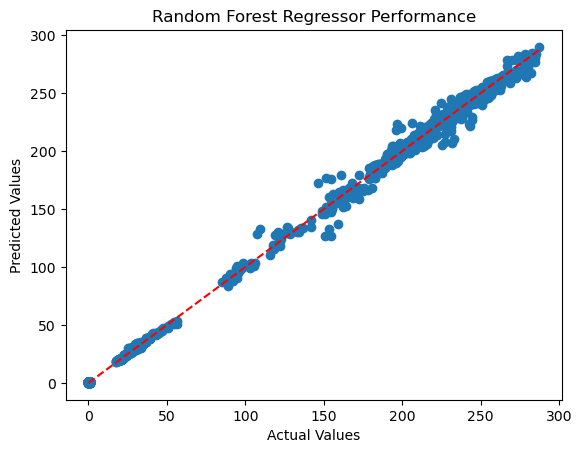

In [61]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regressor Performance")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # reference line
plt.show()

In [62]:
for t, p in zip(y_pred, y_test):
    print('📈', t)
    print('📉', p)

📈 [  0.560149 204.01163  203.70116  206.5425   198.57547 ]
📉 [  1.       204.470001 206.899994 209.199997 204.050003]
📈 [  0.44622552 220.12436    221.56131    224.60997    218.26923   ]
📉 [  1.       221.529999 219.740005 223.800003 217.199997]
📈 [  0.43335027 233.23332    231.7448     234.88934    228.8368    ]
📉 [  0.       230.389999 226.050003 232.889999 225.169998]
📈 [  0.49680892 201.77841    202.81898    205.45995    198.50464   ]
📉 [  0.       202.699997 197.330002 203.339996 195.830002]
📈 [9.9364422e-02 2.7843079e+02 2.7890228e+02 2.8984503e+02 2.7406165e+02]
📉 [  1.       279.029999 280.980011 287.390015 278.609985]
📈 [ 0.683688 20.078627 20.443142 20.485428 20.142937]
📉 [ 1.       20.16     20.65     20.690001 20.040001]
📈 [  0.6280477 200.98009   201.10403   203.07814   197.72066  ]
📉 [  0.       202.       195.649994 204.589996 194.529999]
📈 [  0.42210788 189.01222    189.27382    193.59084    188.13031   ]
📉 [  0.       191.       189.399994 191.889999 187.5     ]
📈 [  0

In [69]:
model_svc_classifier = SVC(
    kernel='rbf',
    C=1.0,
    random_state=42
)

model_svc_classifier.fit(x_train, y_train[:,0])

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [70]:
y_pred = model_svc_classifier.predict(x_test)

Accuracy: 0.5191740412979351

Classification Report:
               precision    recall  f1-score   support

         0.0       0.58      0.15      0.24       170
         1.0       0.51      0.89      0.65       169

    accuracy                           0.52       339
   macro avg       0.54      0.52      0.44       339
weighted avg       0.54      0.52      0.44       339

Axes(0.125,0.11;0.62x0.77)


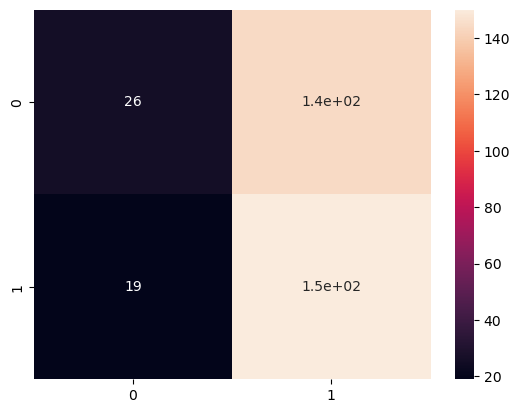

In [71]:
print("Accuracy:", accuracy_score(y_test[:,0], y_pred))
print("\nClassification Report:\n", classification_report(y_test[:,0], y_pred))
print(sns.heatmap(confusion_matrix(y_test[:,0], y_pred), annot=True))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.datasets import load_iris

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVC": SVC(kernel='rbf', probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

# Step 5: Train, predict, and evaluate
results = []

for name, model in models.items():
    model.fit(x_train, y_train[:,0])
    y_pred = model.predict(x_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test[:,0], y_pred),
        "Precision": precision_score(y_test[:,0], y_pred, average='weighted'),
        "Recall": recall_score(y_test[:,0], y_pred, average='weighted'),
        "F1 Score": f1_score(y_test[:,0], y_pred, average='weighted')
    })

# Step 6: Create DataFrame of results
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
2                  SVC  0.519174   0.544091  0.519174  0.444305
3              XGBoost  0.510324   0.510324  0.510324  0.510324
0  Logistic Regression  0.501475   0.504250  0.501475  0.442275
1        Random Forest  0.439528   0.439511  0.439528  0.439382


/home/bigben/miniconda3/envs/data_analysis/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:27:51] WARNING: /croot/xgboost-split_1749630910898/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [91]:
results_df.head()

,Model,Accuracy,Precision,Recall,F1 Score
2,SVC,0.519174,0.544091,0.519174,0.444305
3,XGBoost,0.510324,0.510324,0.510324,0.510324
0,Logistic Regression,0.501475,0.504250,0.501475,0.442275
1,Random Forest,0.439528,0.439511,0.439528,0.439382


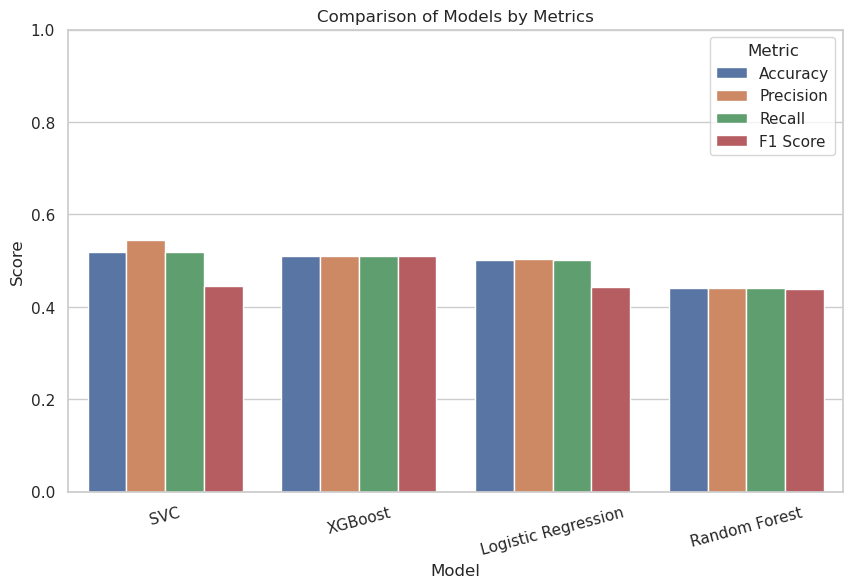

In [95]:
df_melt = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Step 3: Plot using Seaborn
plt.figure(figsize=(10,6))
sns.barplot(data=df_melt, x='Model', y='Score', hue='Metric')
plt.title("Comparison of Models by Metrics")
plt.ylim(0, 1)  # Since metrics are between 0 and 1
plt.xticks(rotation=15)
plt.legend(title='Metric')
plt.show()


In [96]:
raw_total.head()

,Date,Open,High,Low,Close,Volume,day,month,year,is_quarter_end,open-close,low-high,target,next_open,next_close,next_high,next_low
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,29,6,2010,1,-4.889999,-7.459999,0,25.790001,23.830000,30.420000,23.299999
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,30,6,2010,1,1.960001,-7.120001,0,25.000000,21.959999,25.920000,20.270000
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,1,7,2010,0,3.040001,-5.650000,0,23.000000,19.200001,23.100000,18.709999
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,2,7,2010,0,3.799999,-4.390001,0,20.000000,16.110001,20.000000,15.830000
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,6,7,2010,0,3.889999,-4.170000,0,16.400000,15.800000,16.629999,14.980000


In [98]:
raw_total.describe()

,Open,High,Low,Close,Volume,day,month,year,is_quarter_end,open-close,low-high,target,next_open,next_close,next_high,next_low
count,1691.000000,1691.000000,1691.000000,1691.000000,1.691000e+03,1691.000000,1691.000000,1691.000000,1691.000000,1691.000000,1691.000000,1691.000000,1691.000000,1691.000000,1691.000000,1691.000000
mean,132.363773,134.692490,129.918634,132.352330,4.269437e+06,15.675931,6.626257,2013.338261,0.334122,0.011443,-4.773856,0.512123,132.508658,132.492845,134.834613,130.062726
std,94.283494,95.670491,92.827814,94.288796,4.296907e+06,8.752562,3.471080,1.972970,0.471822,3.693800,4.071611,0.500001,94.297430,94.304112,95.685951,92.842380
min,16.139999,16.629999,14.980000,15.800000,1.185000e+05,1.000000,1.000000,2010.000000,0.000000,-20.770004,-36.399994,0.000000,16.139999,15.800000,16.629999,14.980000
25%,30.000000,30.650000,29.210000,29.880000,1.193900e+06,8.000000,4.000000,2012.000000,0.000000,-1.075005,-7.065002,0.000000,30.000000,29.899999,30.680000,29.229999
50%,155.669998,162.300003,153.000000,157.100006,3.180500e+06,16.000000,7.000000,2013.000000,0.000000,0.049999,-4.149994,1.000000,157.000000,159.220001,162.440002,153.300003
75%,220.519996,223.930001,217.065002,220.014999,5.651150e+06,23.000000,10.000000,2015.000000,1.000000,1.245002,-1.245000,1.000000,220.574997,220.025002,224.139999,217.129998
max,287.670013,291.420013,280.399994,286.040009,3.716390e+07,31.000000,12.000000,2017.000000,1.000000,20.509994,-0.250000,1.000000,287.670013,286.040009,291.420013,280.399994


In [99]:
raw_total.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1691 entries, 0 to 1690
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1691 non-null   object 
 1   Open            1691 non-null   float64
 2   High            1691 non-null   float64
 3   Low             1691 non-null   float64
 4   Close           1691 non-null   float64
 5   Volume          1691 non-null   int64  
 6   day             1691 non-null   int64  
 7   month           1691 non-null   int64  
 8   year            1691 non-null   int64  
 9   is_quarter_end  1691 non-null   int64  
 10  open-close      1691 non-null   float64
 11  low-high        1691 non-null   float64
 12  target          1691 non-null   int64  
 13  next_open       1691 non-null   float64
 14  next_close      1691 non-null   float64
 15  next_high       1691 non-null   float64
 16  next_low        1691 non-null   float64
dtypes: float64(10), int64(6), object(1)
me

In [101]:
raw_total.to_hdf('tesla_preprocessed.h5', key='tesla_price', mode='w')